<a href="https://colab.research.google.com/github/MoisesEstrada/Bayesion_Regressor_Model/blob/main/Bayesian_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Modelos de prediccion para consumo de combuistible con bayesian regressor***

#Configuración inicial

In [98]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manejo de rutas y lectura del archivo original
from pathlib import Path
import re
import warnings

# Ocultar advertencias que no afectan la ejecución
warnings.filterwarnings("ignore")

# Manejo y análisis de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Guardado del modelo entrenado
import joblib

# Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import BayesianRidge

# División y validación
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

# Construcción de pipelines
from sklearn.pipeline import Pipeline

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configurar pandas para visualizar todas las columnas
pd.set_option("display.max_columns", None)

# Semilla para obtener resultados reproducibles
RANDOM_STATE = 42

In [99]:
# ============================================================
# DEFINICIÓN DE LAS RUTAS DE GOOGLE DRIVE
# ============================================================

# Carpeta donde se encuentran los archivos del dataset
RUTA_CARPETA = Path(
    "/content/drive/MyDrive/Mineria/auto+mpg"
)

# Ruta del dataset original
RUTA_DATASET = RUTA_CARPETA / "auto-mpg.data-original"

# Ruta del archivo que contiene la descripción del dataset
RUTA_DESCRIPCION = RUTA_CARPETA / "auto-mpg.names"

# Verificar que los archivos existan
print("Ruta del dataset:", RUTA_DATASET)
print("¿Existe el dataset?", RUTA_DATASET.exists())
print("¿Existe la descripción?", RUTA_DESCRIPCION.exists())

# Detener el notebook si no se encuentra el dataset
if not RUTA_DATASET.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en: {RUTA_DATASET}"
    )

Ruta del dataset: /content/drive/MyDrive/Mineria/auto+mpg/auto-mpg.data-original
¿Existe el dataset? True
¿Existe la descripción? True


#Business Understanding

##Determine Business Objectives

El rendimiento de combustible constituye una característica importante para evaluar la eficiencia de los automóviles. Un vehículo con un valor elevado de MPG puede recorrer una mayor distancia utilizando la misma cantidad de combustible.

El problema consiste en estimar el rendimiento de combustible de un automóvil utilizando características como su peso, potencia, cilindrada, número de cilindros, aceleración, año del modelo y lugar de origen.

##Assess Situation

#### Recursos disponibles

- Dataset Auto MPG original.
- Google Drive para almacenar los archivos.
- Google Colab como entorno de ejecución.
- Python, Pandas, Matplotlib y Scikit-learn.
- Modelo Bayesian Ridge Regression.

#### Requisitos

- Trabajar directamente con `auto-mpg.data-original`.
- Aplicar las fases de la metodología CRISP-DM.
- Emplear Bayesian Regressor(Ridge) como modelo principal.
- Evaluar el modelo mediante métricas de regresión.

##Determine Data Mining Goals

El objetivo de minería de datos es construir un modelo supervisado de regresión capaz de predecir la variable continua MPG utilizando las características técnicas del automóvil.

#### Variable objetivo

- `mpg`: millas recorridas por galón.

#### Variables predictoras iniciales

- cylinders
- displacement
- horsepower
- weight
- acceleration
- model_year
- origin

#### Criterios de éxito de minería de datos

- R² de prueba igual o superior a 0.80.
- MAE de prueba inferior a 3 MPG.
- Diferencia reducida entre entrenamiento y prueba.
- Resultados estables mediante validación cruzada.

#Data Understanding

##Collect Initial Data

In [100]:
# ============================================================
# LECTURA DE LA DESCRIPCIÓN DEL DATASET
# ============================================================

if RUTA_DESCRIPCION.exists():
    descripcion_dataset = RUTA_DESCRIPCION.read_text(
        encoding="utf-8",
        errors="replace"
    )

    # Mostrar los primeros 3000 caracteres de la documentación
    print(descripcion_dataset[:3000])
else:
    print("No se encontró el archivo auto-mpg.names.")

1. Title: Auto-Mpg Data

2. Sources:
   (a) Origin:  This dataset was taken from the StatLib library which is
                maintained at Carnegie Mellon University. The dataset was 
                used in the 1983 American Statistical Association Exposition.
   (c) Date: July 7, 1993

3. Past Usage:
    -  See 2b (above)
    -  Quinlan,R. (1993). Combining Instance-Based and Model-Based Learning.
       In Proceedings on the Tenth International Conference of Machine 
       Learning, 236-243, University of Massachusetts, Amherst. Morgan
       Kaufmann.

4. Relevant Information:

   This dataset is a slightly modified version of the dataset provided in
   the StatLib library.  In line with the use by Ross Quinlan (1993) in
   predicting the attribute "mpg", 8 of the original instances were removed 
   because they had unknown values for the "mpg" attribute.  The original 
   dataset is available in the file "auto-mpg.data-original".

   "The data concerns city-cycle fuel consumptio

In [101]:
# ============================================================
# LECTURA DEL DATASET ORIGINAL
# ============================================================

# Nombres de las variables según la documentación del dataset
columnas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

# Listas para almacenar los registros válidos e inválidos
registros = []
lineas_invalidas = []

# Expresión regular para separar las ocho variables iniciales
# y conservar el nombre completo del vehículo entre comillas
patron = re.compile(
    r'^\s*(\S+)\s+'
    r'(\S+)\s+'
    r'(\S+)\s+'
    r'(\S+)\s+'
    r'(\S+)\s+'
    r'(\S+)\s+'
    r'(\S+)\s+'
    r'(\S+)\s+'
    r'"(.*)"\s*$'
)

# Abrir y recorrer el archivo línea por línea
with open(
    RUTA_DATASET,
    mode="r",
    encoding="utf-8",
    errors="replace"
) as archivo:

    for numero_linea, linea in enumerate(archivo, start=1):

        coincidencia = patron.match(linea)

        if coincidencia:
            # Guardar los nueve campos encontrados
            registros.append(coincidencia.groups())
        else:
            # Registrar cualquier línea que no tenga el formato esperado
            lineas_invalidas.append(
                {
                    "numero_linea": numero_linea,
                    "contenido": linea.strip()
                }
            )

# Construir el DataFrame
df = pd.DataFrame(
    registros,
    columns=columnas
)

print("Registros leídos:", len(df))
print("Líneas no interpretadas:", len(lineas_invalidas))

display(df.head())

Registros leídos: 406
Líneas no interpretadas: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.,307.0,130.0,3504.,12.0,70.,1.,chevrolet chevelle malibu
1,15.0,8.,350.0,165.0,3693.,11.5,70.,1.,buick skylark 320
2,18.0,8.,318.0,150.0,3436.,11.0,70.,1.,plymouth satellite
3,16.0,8.,304.0,150.0,3433.,12.0,70.,1.,amc rebel sst
4,17.0,8.,302.0,140.0,3449.,10.5,70.,1.,ford torino


In [102]:
# ============================================================
# CONVERSIÓN DE TIPOS DE DATOS
# ============================================================

columnas_numericas_originales = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

# Convertir las columnas a valores numéricos
# Los valores NA se convertirán en NaN
for columna in columnas_numericas_originales:
    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

print("Conversión de tipos completada.")
display(df.dtypes.to_frame("Tipo de dato"))

Conversión de tipos completada.


,Tipo de dato
mpg,float64
cylinders,float64
displacement,float64
horsepower,float64
weight,float64
acceleration,float64
model_year,float64
origin,float64
car_name,object


##Describe Data


In [103]:
# ============================================================
# DESCRIPCIÓN GENERAL DEL DATASET
# ============================================================

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

print("\nPrimeros registros:")
display(df.head())

print("\nÚltimos registros:")
display(df.tail())

print("\nInformación de las variables:")
df.info()

print("\nResumen estadístico:")
display(df.describe().T)

Número de filas: 406
Número de columnas: 9

Primeros registros:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino



Últimos registros:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
401,27.0,4.0,140.0,86.0,2790.0,15.6,82.0,1.0,ford mustang gl
402,44.0,4.0,97.0,52.0,2130.0,24.6,82.0,2.0,vw pickup
403,32.0,4.0,135.0,84.0,2295.0,11.6,82.0,1.0,dodge rampage
404,28.0,4.0,120.0,79.0,2625.0,18.6,82.0,1.0,ford ranger
405,31.0,4.0,119.0,82.0,2720.0,19.4,82.0,1.0,chevy s-10



Información de las variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     406 non-null    float64
 2   displacement  406 non-null    float64
 3   horsepower    400 non-null    float64
 4   weight        406 non-null    float64
 5   acceleration  406 non-null    float64
 6   model_year    406 non-null    float64
 7   origin        406 non-null    float64
 8   car_name      406 non-null    object 
dtypes: float64(8), object(1)
memory usage: 28.7+ KB

Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.50,23.0,29.000,46.6
cylinders,406.0,5.475369,1.712160,3.0,4.00,4.0,8.000,8.0
displacement,406.0,194.779557,104.922458,68.0,105.00,151.0,302.000,455.0
horsepower,400.0,105.082500,38.768779,46.0,75.75,95.0,130.000,230.0
weight,406.0,2979.413793,847.004328,1613.0,2226.50,2822.5,3618.250,5140.0
acceleration,406.0,15.519704,2.803359,8.0,13.70,15.5,17.175,24.8
model_year,406.0,75.921182,3.748737,70.0,73.00,76.0,79.000,82.0
origin,406.0,1.568966,0.797479,1.0,1.00,1.0,2.000,3.0


In [104]:
# ============================================================
# DICCIONARIO DE VARIABLES
# ============================================================

diccionario_variables = pd.DataFrame({
    "Variable": [
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year",
        "origin",
        "car_name"
    ],
    "Tipo": [
        "Numérica continua",
        "Numérica discreta",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Numérica ordinal",
        "Categórica",
        "Texto"
    ],
    "Descripción": [
        "Millas recorridas por galón",
        "Número de cilindros",
        "Desplazamiento del motor",
        "Potencia del motor",
        "Peso del automóvil",
        "Tiempo de aceleración",
        "Año del modelo",
        "Región de origen: 1=EE.UU., 2=Europa, 3=Japón",
        "Nombre del automóvil"
    ]
})

display(diccionario_variables)

,Variable,Tipo,Descripción
0,mpg,Numérica continua,Millas recorridas por galón
1,cylinders,Numérica discreta,Número de cilindros
2,displacement,Numérica continua,Desplazamiento del motor
3,horsepower,Numérica continua,Potencia del motor
4,weight,Numérica continua,Peso del automóvil
5,acceleration,Numérica continua,Tiempo de aceleración
6,model_year,Numérica ordinal,Año del modelo
7,origin,Categórica,"Región de origen: 1=EE.UU., 2=Europa, 3=Japón"
8,car_name,Texto,Nombre del automóvil


##Explore Data

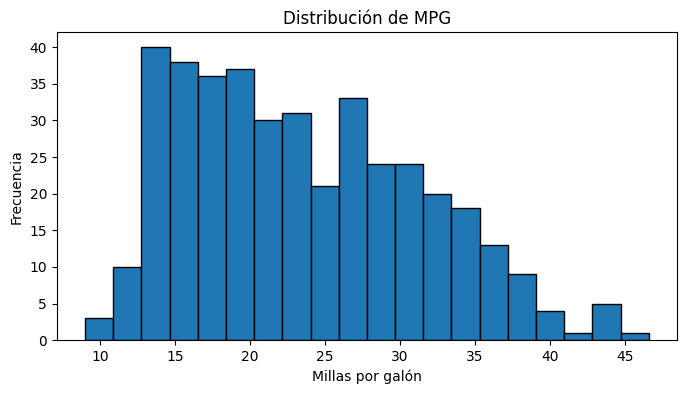

In [105]:
# ============================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

plt.figure(figsize=(8, 4))

# Excluir temporalmente los valores faltantes
plt.hist(
    df["mpg"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de MPG")
plt.xlabel("Millas por galón")
plt.ylabel("Frecuencia")
plt.show()

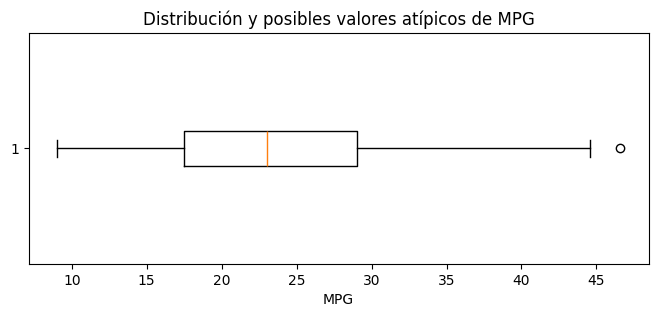

In [106]:
# ============================================================
# BOXPLOT DE LA VARIABLE OBJETIVO
# ============================================================

plt.figure(figsize=(8, 3))

plt.boxplot(
    df["mpg"].dropna(),
    vert=False
)

plt.title("Distribución y posibles valores atípicos de MPG")
plt.xlabel("MPG")
plt.show()

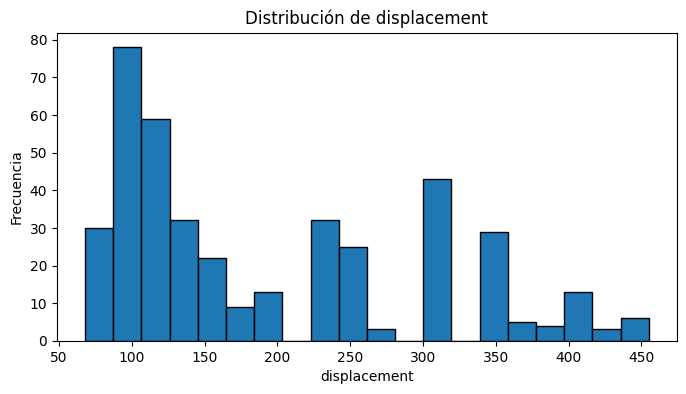

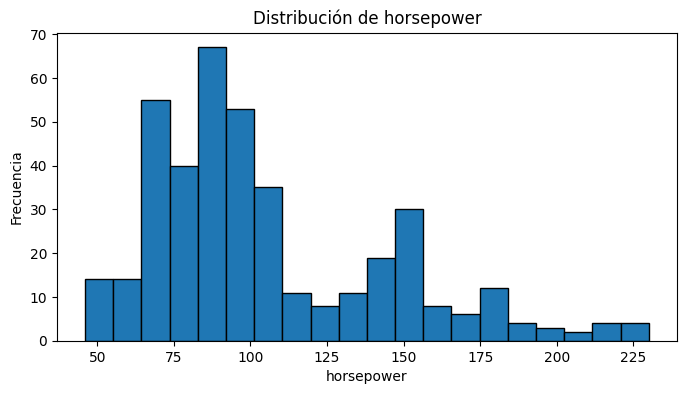

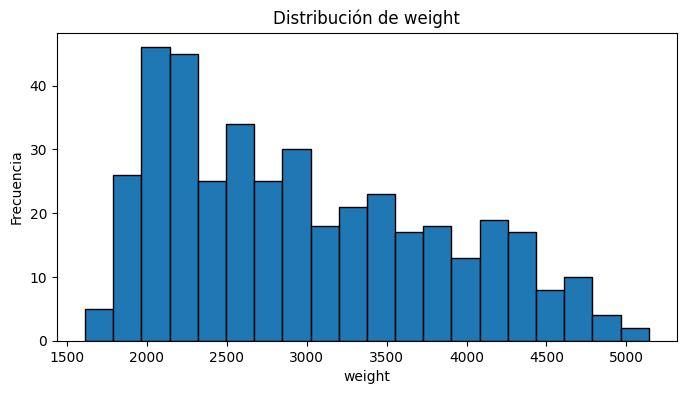

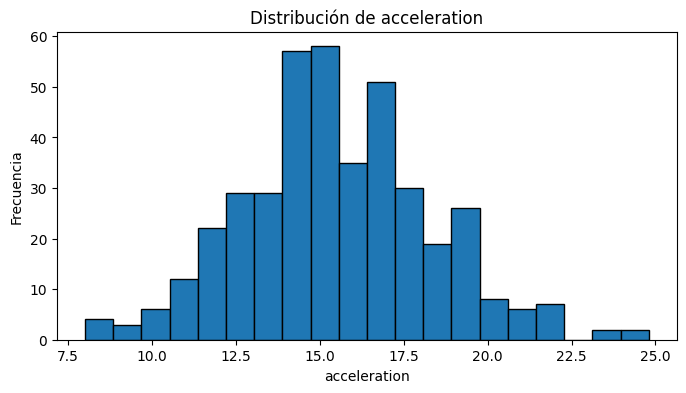

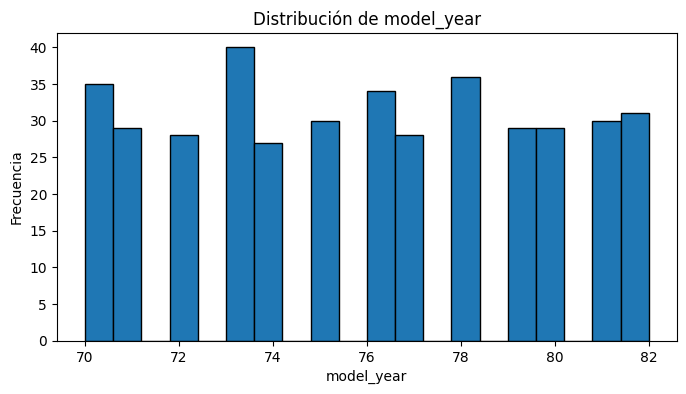

In [107]:
# ============================================================
# DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS
# ============================================================

variables_continuas_eda = [
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

for variable in variables_continuas_eda:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[variable].dropna(),
        bins=20,
        edgecolor="black"
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

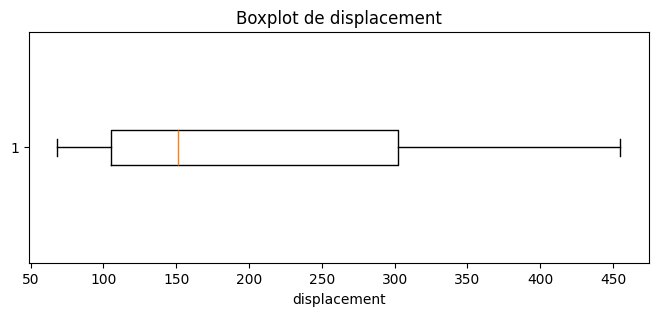

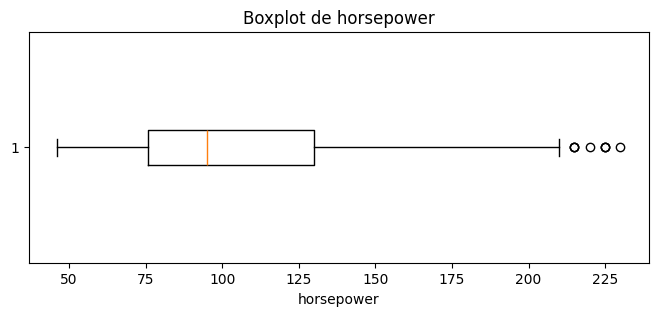

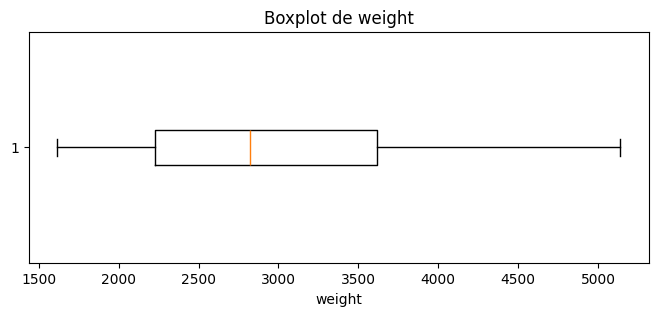

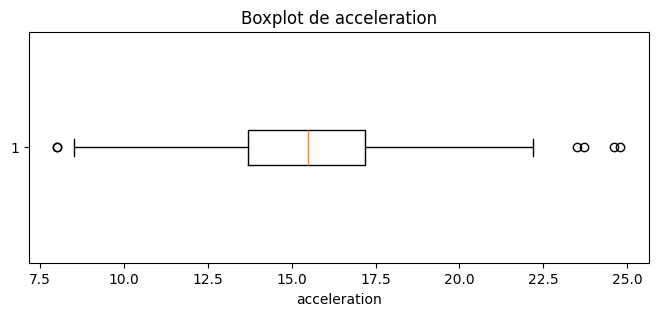

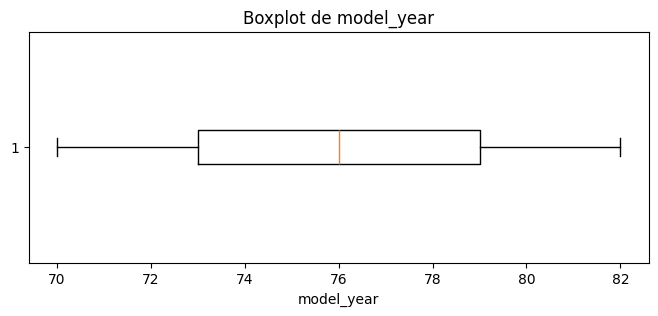

In [108]:
# ============================================================
# BOXPLOTS DE VARIABLES NUMÉRICAS
# ============================================================

for variable in variables_continuas_eda:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[variable].dropna(),
        vert=False
    )

    plt.title(f"Boxplot de {variable}")
    plt.xlabel(variable)
    plt.show()

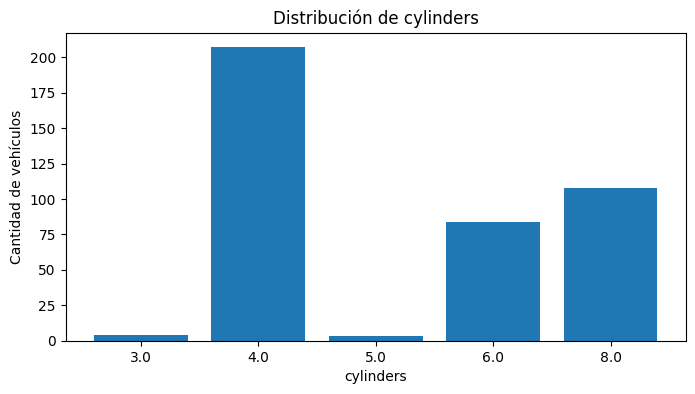

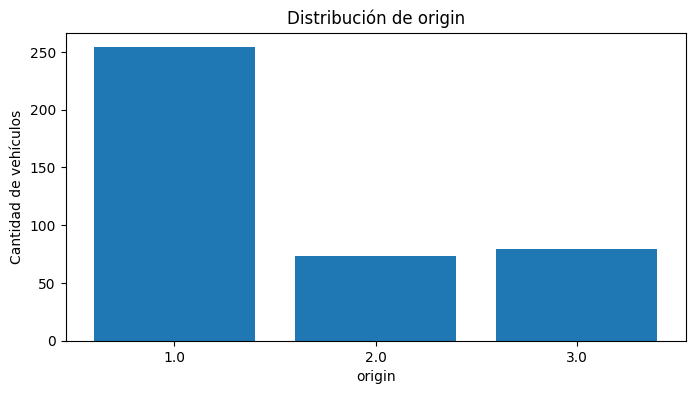

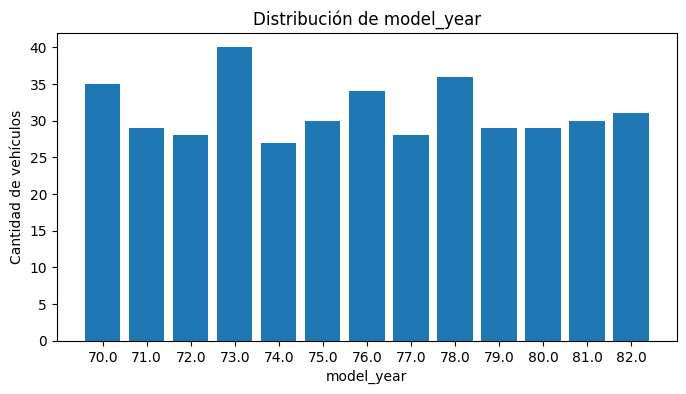

In [109]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES DISCRETAS Y CATEGÓRICAS
# ============================================================

variables_discretas = [
    "cylinders",
    "origin",
    "model_year"
]

for variable in variables_discretas:

    frecuencias = (
        df[variable]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))

    plt.bar(
        frecuencias.index.astype(str),
        frecuencias.values
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Cantidad de vehículos")
    plt.show()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000,-0.775,-0.804,-0.778,-0.832,0.420,0.579,0.563
cylinders,-0.775,1.000,0.952,0.844,0.895,-0.522,-0.361,-0.567
displacement,-0.804,0.952,1.000,0.898,0.932,-0.558,-0.382,-0.613
horsepower,-0.778,0.844,0.898,1.000,0.867,-0.697,-0.424,-0.460
weight,-0.832,0.895,0.932,0.867,1.000,-0.430,-0.315,-0.584
acceleration,0.420,-0.522,-0.558,-0.697,-0.430,1.000,0.302,0.219
model_year,0.579,-0.361,-0.382,-0.424,-0.315,0.302,1.000,0.188
origin,0.563,-0.567,-0.613,-0.460,-0.584,0.219,0.188,1.000


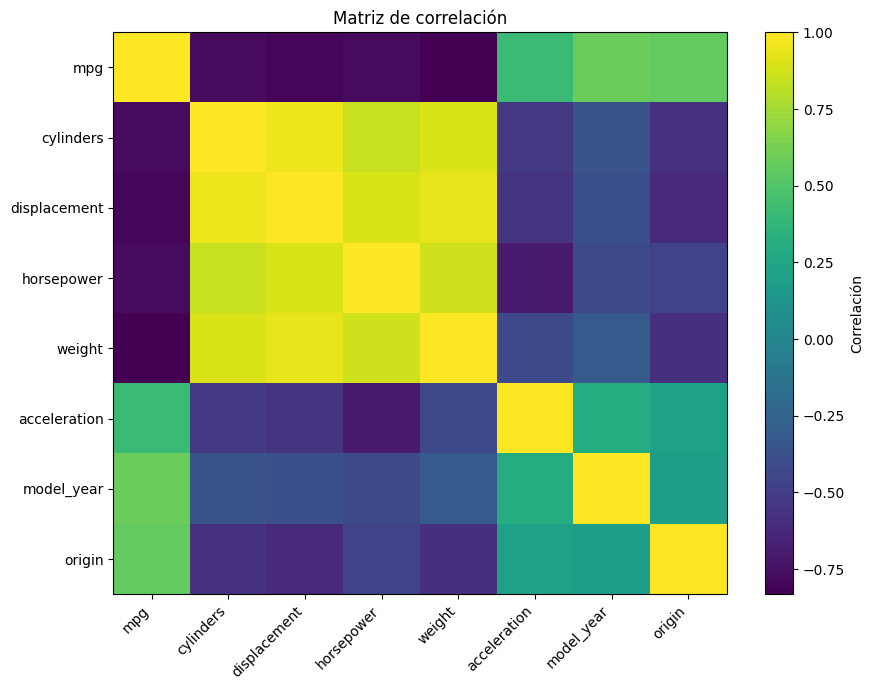

Correlaciones con MPG:


,Correlación con MPG
weight,-0.831741
displacement,-0.804203
horsepower,-0.778427
cylinders,-0.775396
acceleration,0.420289
origin,0.563450
model_year,0.579267
mpg,1.000000


In [110]:
# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================

columnas_correlacion = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

# Calcular correlaciones lineales
matriz_correlacion = df[columnas_correlacion].corr()

# Mostrar los valores numéricos
display(matriz_correlacion.round(3))

# Representar la matriz gráficamente
plt.figure(figsize=(9, 7))

plt.imshow(
    matriz_correlacion,
    aspect="auto"
)

plt.xticks(
    range(len(columnas_correlacion)),
    columnas_correlacion,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(columnas_correlacion)),
    columnas_correlacion
)

plt.colorbar(label="Correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Mostrar las correlaciones específicas con MPG
print("Correlaciones con MPG:")
display(
    matriz_correlacion["mpg"]
    .sort_values()
    .to_frame("Correlación con MPG")
)

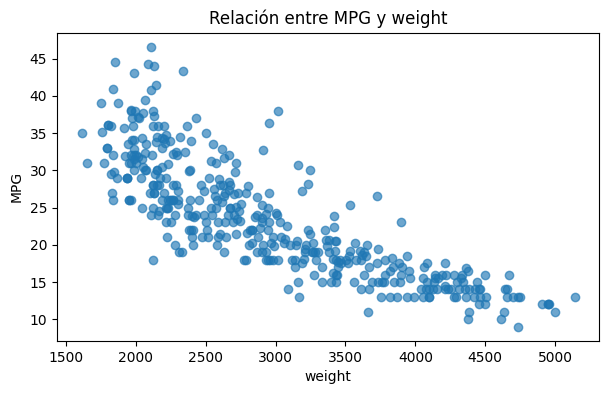

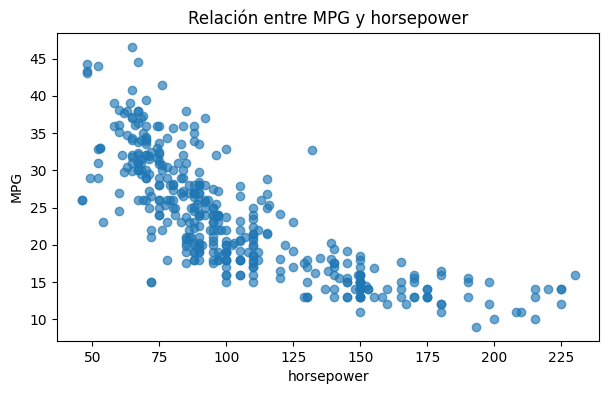

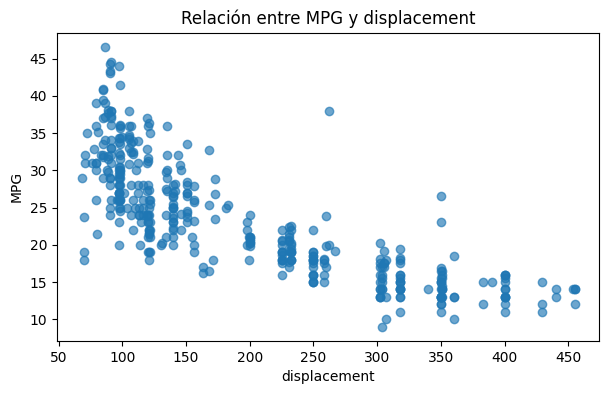

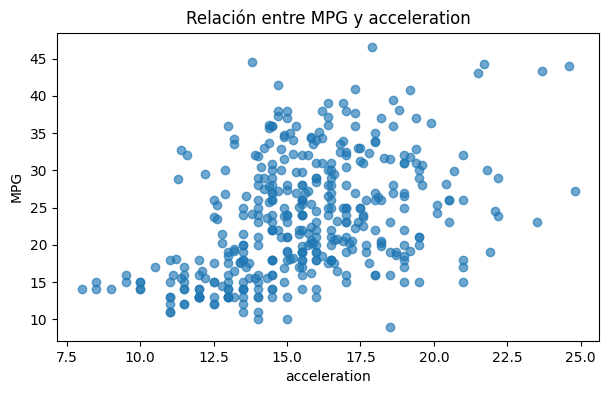

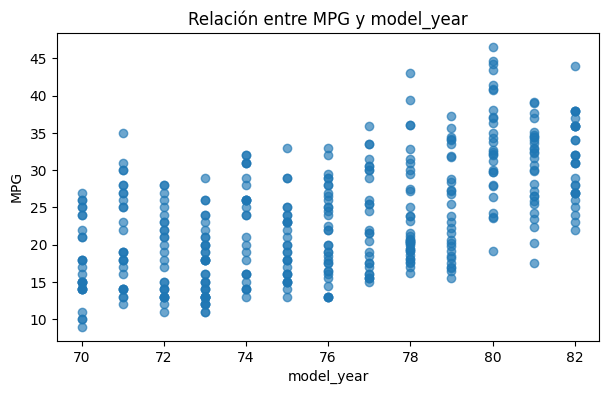

In [111]:
# ============================================================
# RELACIÓN ENTRE MPG Y LAS VARIABLES PREDICTORAS
# ============================================================

variables_relacion = [
    "weight",
    "horsepower",
    "displacement",
    "acceleration",
    "model_year"
]

for variable in variables_relacion:

    # Eliminar valores faltantes únicamente para el gráfico
    datos_grafico = df[["mpg", variable]].dropna()

    plt.figure(figsize=(7, 4))

    plt.scatter(
        datos_grafico[variable],
        datos_grafico["mpg"],
        alpha=0.65
    )

    plt.xlabel(variable)
    plt.ylabel("MPG")
    plt.title(f"Relación entre MPG y {variable}")
    plt.show()

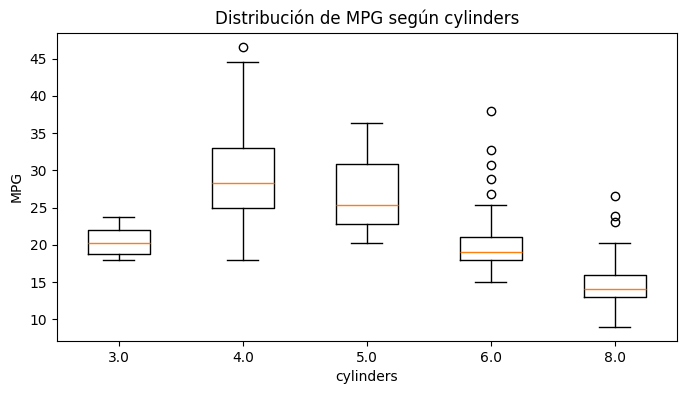

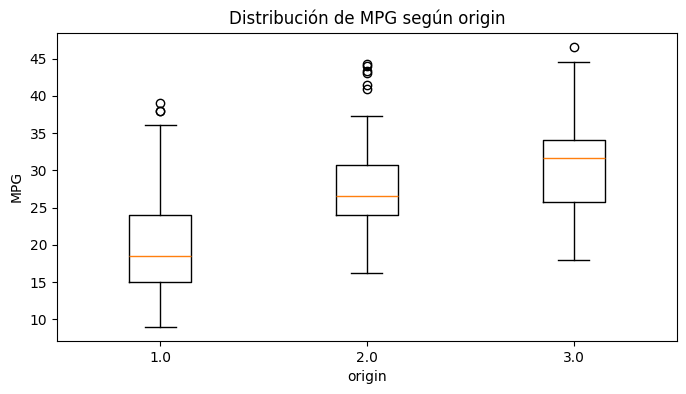

In [112]:
# ============================================================
# MPG SEGÚN VARIABLES CATEGÓRICAS
# ============================================================

for variable in ["cylinders", "origin"]:

    # Obtener las categorías ordenadas
    categorias = sorted(df[variable].dropna().unique())

    # Crear una lista de MPG para cada categoría
    valores = [
        df.loc[df[variable] == categoria, "mpg"].dropna()
        for categoria in categorias
    ]

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        valores,
        labels=[str(categoria) for categoria in categorias]
    )

    plt.title(f"Distribución de MPG según {variable}")
    plt.xlabel(variable)
    plt.ylabel("MPG")
    plt.show()

##Verify Data Quality

In [113]:
# ============================================================
# VERIFICACIÓN DE LA CALIDAD DE LOS DATOS
# ============================================================

print("Dimensión del dataset:", df.shape)

print("\nCantidad de duplicados completos:")
print(df.duplicated().sum())

print("\nValores faltantes por variable:")
display(
    df.isna()
    .sum()
    .to_frame("Valores faltantes")
)

print("\nPorcentaje de valores faltantes:")
porcentaje_faltantes = (
    df.isna().mean() * 100
).round(2)

display(
    porcentaje_faltantes
    .to_frame("Porcentaje faltante")
)

print("\nCantidad de valores únicos:")
display(
    df.nunique()
    .to_frame("Valores únicos")
)

Dimensión del dataset: (406, 9)

Cantidad de duplicados completos:
0

Valores faltantes por variable:


,Valores faltantes
mpg,8
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0



Porcentaje de valores faltantes:


,Porcentaje faltante
mpg,1.97
cylinders,0.00
displacement,0.00
horsepower,1.48
weight,0.00
acceleration,0.00
model_year,0.00
origin,0.00
car_name,0.00



Cantidad de valores únicos:


,Valores únicos
mpg,129
cylinders,5
displacement,83
horsepower,93
weight,356
acceleration,96
model_year,13
origin,3
car_name,312


In [114]:
# ============================================================
# DETECCIÓN DE POSIBLES VALORES ATÍPICOS MEDIANTE IQR
# ============================================================

def resumen_outliers_iqr(dataframe, columnas):
    """
    Calcula la cantidad de posibles valores atípicos de cada
    variable utilizando el rango intercuartílico.
    """

    resultados = []

    for columna in columnas:

        # Excluir temporalmente los valores faltantes
        datos = dataframe[columna].dropna()

        # Calcular los cuartiles
        q1 = datos.quantile(0.25)
        q3 = datos.quantile(0.75)

        # Calcular el rango intercuartílico
        iqr = q3 - q1

        # Límites para detectar valores atípicos
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        # Identificar los valores fuera de los límites
        cantidad_outliers = (
            (datos < limite_inferior) |
            (datos > limite_superior)
        ).sum()

        resultados.append({
            "Variable": columna,
            "Q1": q1,
            "Q3": q3,
            "Límite inferior": limite_inferior,
            "Límite superior": limite_superior,
            "Posibles outliers": cantidad_outliers
        })

    return pd.DataFrame(resultados)


variables_revision_outliers = [
    "mpg",
    "displacement",
    "horsepower",
    "weight",
    "acceleration"
]

tabla_outliers = resumen_outliers_iqr(
    df,
    variables_revision_outliers
)

display(tabla_outliers.round(2))

,Variable,Q1,Q3,Límite inferior,Límite superior,Posibles outliers
0,mpg,17.50,29.00,0.25,46.25,1
1,displacement,105.00,302.00,-190.50,597.50,0
2,horsepower,75.75,130.00,-5.62,211.38,8
3,weight,2226.50,3618.25,138.88,5705.88,0
4,acceleration,13.70,17.18,8.49,22.39,6


#Data Preparation

##SELECT DATA

In [115]:
# ============================================================
# SELECCIÓN DE LOS DATOS
# ============================================================

# Separar los registros que tienen MPG conocido
# Estos registros se utilizarán para entrenar y evaluar
df_modelo = (
    df.dropna(subset=["mpg"])
    .copy()
)

# Separar los registros cuyo MPG es desconocido
# Estos registros se predecirán durante el despliegue
df_mpg_desconocido = (
    df[df["mpg"].isna()]
    .copy()
)

print("Registros con MPG conocido:", len(df_modelo))
print("Registros con MPG desconocido:", len(df_mpg_desconocido))

Registros con MPG conocido: 398
Registros con MPG desconocido: 8


##CLEAN DATA

In [116]:
# ============================================================
# LIMPIEZA DE LOS DATOS
# ============================================================

# Revisar la cantidad de duplicados antes de eliminarlos
duplicados_antes = df_modelo.duplicated().sum()

# Eliminar únicamente duplicados completamente idénticos
df_modelo = (
    df_modelo
    .drop_duplicates()
    .copy()
)

duplicados_despues = df_modelo.duplicated().sum()

print("Duplicados antes:", duplicados_antes)
print("Duplicados después:", duplicados_despues)

# No se imputa MPG porque es la variable objetivo.
# Horsepower será imputada posteriormente dentro del pipeline
# para evitar fuga de información.

Duplicados antes: 0
Duplicados después: 0


##CONSTRUCT DATA

In [117]:
# ============================================================
# CONSTRUCCIÓN DE UNA VARIABLE DERIVADA
# ============================================================

# Utilizar el mayor año registrado como año de referencia
ANIO_REFERENCIA = int(df_modelo["model_year"].max())

# Calcular la antigüedad relativa del vehículo
df_modelo["vehicle_age"] = (
    ANIO_REFERENCIA -
    df_modelo["model_year"]
)

# Crear la misma variable en los registros con MPG desconocido
df_mpg_desconocido["vehicle_age"] = (
    ANIO_REFERENCIA -
    df_mpg_desconocido["model_year"]
)

print("Año de referencia:", ANIO_REFERENCIA)

display(
    df_modelo[
        ["model_year", "vehicle_age"]
    ].head()
)

Año de referencia: 82


,model_year,vehicle_age
0,70.0,12.0
1,70.0,12.0
2,70.0,12.0
3,70.0,12.0
4,70.0,12.0


##INTEGRATE DATA

No fue necesario integrar diferentes fuentes de información, debido a que las características predictoras y la variable objetivo se encuentran en un único archivo denominado `auto-mpg.data-original`.

##FORMAT DATA

In [118]:
# ============================================================
# CLASIFICACIÓN DE LAS VARIABLES
# ============================================================

# Variables numéricas continuas que serán imputadas y escaladas
variables_numericas = [
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "vehicle_age"
]

# Variables discretas tratadas como categorías
variables_categoricas = [
    "cylinders",
    "origin"
]

# Orden final de las variables utilizadas por el modelo
columnas_modelo = (
    variables_numericas +
    variables_categoricas
)

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['displacement', 'horsepower', 'weight', 'acceleration', 'vehicle_age']
Variables categóricas: ['cylinders', 'origin']


In [119]:
# ============================================================
# DEFINICIÓN DE PREDICTORES Y VARIABLE OBJETIVO
# ============================================================

# Seleccionar las variables predictoras
X = df_modelo[columnas_modelo].copy()

# Seleccionar la variable objetivo
y = df_modelo["mpg"].copy()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

display(X.head())
display(y.head())

Dimensión de X: (398, 7)
Dimensión de y: (398,)


,displacement,horsepower,weight,acceleration,vehicle_age,cylinders,origin
0,307.0,130.0,3504.0,12.0,12.0,8.0,1.0
1,350.0,165.0,3693.0,11.5,12.0,8.0,1.0
2,318.0,150.0,3436.0,11.0,12.0,8.0,1.0
3,304.0,150.0,3433.0,12.0,12.0,8.0,1.0
4,302.0,140.0,3449.0,10.5,12.0,8.0,1.0


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [120]:
# ============================================================
# DIVISIÓN DE LOS DATOS
# ============================================================

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

Registros de entrenamiento: 318
Registros de prueba: 80


In [121]:
# ============================================================
# PIPELINE PARA VARIABLES NUMÉRICAS
# ============================================================

pipeline_numerico = Pipeline(
    steps=[
        # Reemplazar valores faltantes con la mediana
        (
            "imputacion",
            SimpleImputer(strategy="median")
        ),

        # Estandarizar las variables para obtener media 0
        # y desviación estándar 1
        (
            "escalamiento",
            StandardScaler()
        )
    ]
)

In [122]:
# ============================================================
# PIPELINE PARA VARIABLES CATEGÓRICAS
# ============================================================

pipeline_categorico = Pipeline(
    steps=[
        # Reemplazar valores faltantes con la categoría más frecuente
        (
            "imputacion",
            SimpleImputer(strategy="most_frequent")
        ),

        # Convertir las categorías en columnas binarias
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [123]:
# ============================================================
# PREPROCESADOR GENERAL
# ============================================================

preprocesador = ColumnTransformer(
    transformers=[
        # Aplicar el pipeline numérico
        (
            "numericas",
            pipeline_numerico,
            variables_numericas
        ),

        # Aplicar el pipeline categórico
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas
        )
    ],

    # Excluir cualquier variable no declarada
    remainder="drop",

    # Simplificar los nombres de las variables transformadas
    verbose_feature_names_out=False
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


#Modeling

###Select Modeling Technique

Se seleccionó Bayesian Regression porque es un modelo de regresión probabilístico que incorpora regularización bayesiana sobre los coeficientes.

Además de producir una estimación puntual, permite calcular la desviación estándar predictiva, lo que facilita la construcción de intervalos de incertidumbre.

También se empleará un DummyRegressor como modelo de referencia. Este modelo siempre predice el promedio de MPG del conjunto de entrenamiento.

###Generate Test Design


In [124]:
# ============================================================
# DISEÑO DE VALIDACIÓN
# ============================================================

# Validación cruzada de cinco particiones
# shuffle=True mezcla los registros antes de crear los grupos
validacion_cruzada = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Diseño de validación:")
print("- División holdout: 80% entrenamiento y 20% prueba")
print("- Validación cruzada: 5 particiones")
print("- Modelo de referencia: DummyRegressor")

Diseño de validación:
- División holdout: 80% entrenamiento y 20% prueba
- Validación cruzada: 5 particiones
- Modelo de referencia: DummyRegressor


###Build Model

In [125]:
# ============================================================
# MODELO DE REFERENCIA
# ============================================================

pipeline_dummy = Pipeline(
    steps=[
        # Aplicar el mismo preprocesamiento
        (
            "preprocesamiento",
            preprocesador
        ),

        # Predecir siempre el promedio de MPG
        (
            "modelo",
            DummyRegressor(strategy="mean")
        )
    ]
)

# Entrenar el modelo de referencia
pipeline_dummy.fit(
    X_train,
    y_train
)

print("DummyRegressor entrenado.")

DummyRegressor entrenado.


In [126]:
# ============================================================
# MODELO BAYESIAN RIDGE
# ============================================================

pipeline_bayesiano = Pipeline(
    steps=[
        # Imputación, escalamiento y codificación
        (
            "preprocesamiento",
            preprocesador
        ),

        # Modelo probabilístico de regresión
        (
            "modelo",
            BayesianRidge()
        )
    ]
)

# Entrenar el pipeline completo
pipeline_bayesiano.fit(
    X_train,
    y_train
)

print("Bayesian Ridge entrenado correctamente.")

Bayesian Ridge entrenado correctamente.


###Assess Model

In [127]:
# ============================================================
# PREDICCIONES INICIALES
# ============================================================

# Predicciones del modelo bayesiano
y_pred_train = pipeline_bayesiano.predict(X_train)
y_pred_test = pipeline_bayesiano.predict(X_test)

# Predicciones del modelo de referencia
y_pred_dummy = pipeline_dummy.predict(X_test)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [128]:
# ============================================================
# PARÁMETROS APRENDIDOS POR BAYESIAN RIDGE
# ============================================================

modelo_entrenado = (
    pipeline_bayesiano
    .named_steps["modelo"]
)

print("Alpha o precisión estimada del ruido:")
print(modelo_entrenado.alpha_)

print("\nLambda o precisión estimada de los coeficientes:")
print(modelo_entrenado.lambda_)

print("\nIntercepto:")
print(modelo_entrenado.intercept_)

print("\nNúmero de iteraciones:")
print(modelo_entrenado.n_iter_)

Alpha o precisión estimada del ruido:
0.09673174425010816

Lambda o precisión estimada de los coeficientes:
0.17849523772049206

Intercepto:
23.221525097571607

Número de iteraciones:
7


In [129]:
# ============================================================
# INTERPRETACIÓN DE LOS COEFICIENTES
# ============================================================

# Obtener los nombres después del preprocesamiento
nombres_variables = (
    pipeline_bayesiano
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

# Obtener los coeficientes aprendidos
coeficientes = (
    pipeline_bayesiano
    .named_steps["modelo"]
    .coef_
)

# Construir una tabla ordenada por importancia absoluta
tabla_coeficientes = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Importancia absoluta": np.abs(coeficientes)
})

tabla_coeficientes = (
    tabla_coeficientes
    .sort_values(
        "Importancia absoluta",
        ascending=False
    )
)

display(tabla_coeficientes.round(4))

,Variable,Coeficiente,Importancia absoluta
2,weight,-4.6781,4.6781
5,cylinders_3.0,-3.2931,3.2931
4,vehicle_age,-2.7551,2.7551
6,cylinders_4.0,1.9786,1.9786
10,origin_1.0,-1.5208,1.5208
0,displacement,1.4230,1.4230
1,horsepower,-1.3176,1.3176
7,cylinders_5.0,1.2352,1.2352
9,cylinders_8.0,1.0593,1.0593
8,cylinders_6.0,-0.9800,0.9800


#Evaluation

###Evaluate Results

In [130]:
# ============================================================
# FUNCIÓN PARA CALCULAR MÉTRICAS
# ============================================================

def calcular_metricas(y_real, y_predicho):
    """
    Calcula las principales métricas de regresión.
    """

    mae = mean_absolute_error(
        y_real,
        y_predicho
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_real,
            y_predicho
        )
    )

    r2 = r2_score(
        y_real,
        y_predicho
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [144]:
# ============================================================
# COMPARACIÓN DE RESULTADOS
# ============================================================

resultados_modelos = pd.DataFrame([
    {
        "Modelo": "Bayesian Ridge",
        "Conjunto": "Entrenamiento",
        **calcular_metricas(
            y_train,
            y_pred_train
        )
    },
    {
        "Modelo": "Bayesian Ridge",
        "Conjunto": "Prueba",
        **calcular_metricas(
            y_test,
            y_pred_test
        )
    },

])

display(
    resultados_modelos.round(4)
)

,Modelo,Conjunto,MAE,RMSE,R2
0,Bayesian Ridge,Entrenamiento,2.3630,3.1651,0.8402
1,Bayesian Ridge,Prueba,2.1316,2.6898,0.8654


In [132]:
# ============================================================
# VALIDACIÓN CRUZADA DEL MODELO BAYESIANO
# ============================================================

resultados_cv = cross_validate(
    pipeline_bayesiano,
    X,
    y,
    cv=validacion_cruzada,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

# Convertir las métricas negativas a valores positivos
mae_cv = -resultados_cv["test_MAE"]
rmse_cv = -resultados_cv["test_RMSE"]
r2_cv = resultados_cv["test_R2"]

resumen_cv = pd.DataFrame({
    "Métrica": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Promedio": [
        mae_cv.mean(),
        rmse_cv.mean(),
        r2_cv.mean()
    ],
    "Desviación estándar": [
        mae_cv.std(),
        rmse_cv.std(),
        r2_cv.std()
    ]
})

display(resumen_cv.round(4))

,Métrica,Promedio,Desviación estándar
0,MAE,2.3686,0.1834
1,RMSE,3.1814,0.3794
2,R²,0.8328,0.0227


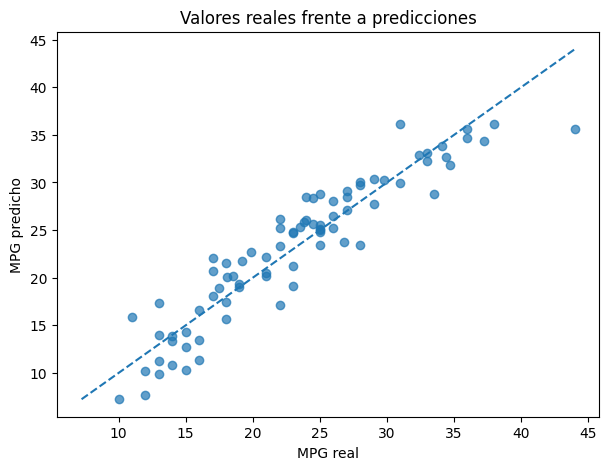

In [133]:
# ============================================================
# VALORES REALES FRENTE A PREDICHOS
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.70
)

# Definir límites para representar la línea de predicción ideal
limite_minimo = min(
    y_test.min(),
    y_pred_test.min()
)

limite_maximo = max(
    y_test.max(),
    y_pred_test.max()
)

# Línea donde predicción y valor real serían iguales
plt.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    linestyle="--"
)

plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Valores reales frente a predicciones")
plt.show()

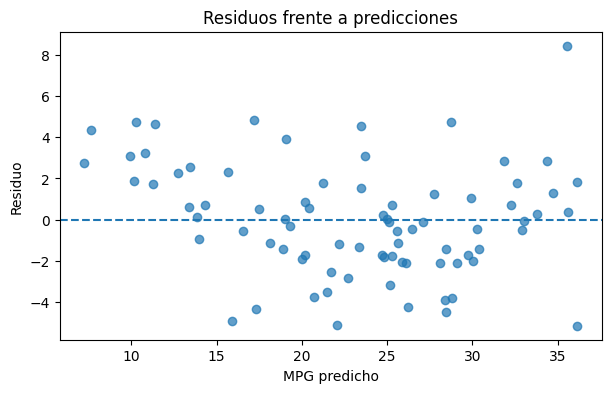

Promedio de los residuos: -0.006247025640651627


In [134]:
# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================

# Residuo = valor real - valor predicho
residuos = (
    y_test.to_numpy() -
    y_pred_test
)

plt.figure(figsize=(7, 4))

plt.scatter(
    y_pred_test,
    residuos,
    alpha=0.70
)

# Línea horizontal que representa residuo igual a cero
plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("MPG predicho")
plt.ylabel("Residuo")
plt.title("Residuos frente a predicciones")
plt.show()

print("Promedio de los residuos:", residuos.mean())

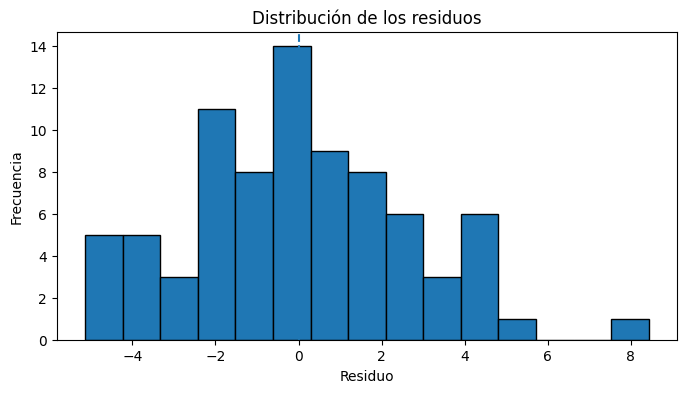

In [135]:
# ============================================================
# DISTRIBUCIÓN DE LOS RESIDUOS
# ============================================================

plt.figure(figsize=(8, 4))

plt.hist(
    residuos,
    bins=15,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()

In [136]:
# ============================================================
# INCERTIDUMBRE PREDICTIVA DE BAYESIAN RIDGE
# ============================================================

# Transformar X_test con el preprocesamiento entrenado
X_test_transformado = (
    pipeline_bayesiano
    .named_steps["preprocesamiento"]
    .transform(X_test)
)

# Obtener predicción media y desviación estándar
media_predicha, desviacion_predicha = (
    pipeline_bayesiano
    .named_steps["modelo"]
    .predict(
        X_test_transformado,
        return_std=True
    )
)

# Construir intervalo predictivo aproximado del 95%
limite_inferior = (
    media_predicha -
    1.96 * desviacion_predicha
)

limite_superior = (
    media_predicha +
    1.96 * desviacion_predicha
)

# Crear tabla de resultados
tabla_incertidumbre = pd.DataFrame({
    "MPG real": y_test.to_numpy(),
    "MPG predicho": media_predicha,
    "Desviación": desviacion_predicha,
    "Límite inferior 95%": limite_inferior,
    "Límite superior 95%": limite_superior
})

display(
    tabla_incertidumbre
    .head(15)
    .round(2)
)

,MPG real,MPG predicho,Desviación,Límite inferior 95%,Límite superior 95%
0,33.0,33.05,3.70,25.79,40.31
1,28.0,30.02,3.72,22.73,37.31
2,19.0,19.31,3.72,12.02,26.60
3,13.0,17.31,3.69,10.07,24.55
4,14.0,13.38,3.70,6.12,20.63
5,27.0,27.11,3.71,19.83,34.38
6,24.0,28.46,3.72,21.17,35.76
7,13.0,9.93,3.74,2.60,17.26
8,17.0,18.11,3.75,10.75,25.46
9,21.0,20.16,3.70,12.91,27.41


##Approved Models

In [137]:
# ============================================================
# VERIFICACIÓN DE CRITERIOS DE APROBACIÓN
# ============================================================

metricas_train = calcular_metricas(
    y_train,
    y_pred_train
)

metricas_test = calcular_metricas(
    y_test,
    y_pred_test
)

metricas_dummy = calcular_metricas(
    y_test,
    y_pred_dummy
)

criterios_aprobacion = pd.DataFrame({
    "Criterio": [
        "R² de prueba igual o superior a 0.80",
        "MAE de prueba inferior a 3 MPG",
        "RMSE menor que DummyRegressor",
        "Diferencia de R² train-test inferior a 0.10"
    ],
    "Cumple": [
        metricas_test["R2"] >= 0.80,
        metricas_test["MAE"] < 3,
        metricas_test["RMSE"] < metricas_dummy["RMSE"],
        abs(
            metricas_train["R2"] -
            metricas_test["R2"]
        ) < 0.10
    ]
})

display(criterios_aprobacion)

# Aprobar únicamente cuando se cumplan todos los criterios
modelo_aprobado = criterios_aprobacion["Cumple"].all()

if modelo_aprobado:
    print("El modelo Bayesian Ridge fue aprobado.")
else:
    print("El modelo necesita revisión antes del despliegue.")

,Criterio,Cumple
0,R² de prueba igual o superior a 0.80,True
1,MAE de prueba inferior a 3 MPG,True
2,RMSE menor que DummyRegressor,True
3,Diferencia de R² train-test inferior a 0.10,True


El modelo Bayesian Ridge fue aprobado.


##Determine Next Steps

In [138]:
# ============================================================
# DETERMINACIÓN DE LOS SIGUIENTES PASOS
# ============================================================

if modelo_aprobado:

    siguiente_paso = (
        "Continuar con el despliegue, reentrenar el modelo "
        "con todos los registros conocidos y predecir los "
        "valores MPG faltantes."
    )

else:

    siguiente_paso = (
        "Regresar a Data Preparation o Modeling para revisar "
        "variables, transformaciones, valores atípicos y "
        "comparar el resultado con modelos no lineales."
    )

print(siguiente_paso)

Continuar con el despliegue, reentrenar el modelo con todos los registros conocidos y predecir los valores MPG faltantes.


#Deployment

##Plan Deployment

In [139]:
# ============================================================
# ENTRENAMIENTO FINAL
# ============================================================

# Entrenar el pipeline utilizando todos los registros con MPG conocido
pipeline_final = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador
        ),
        (
            "modelo",
            BayesianRidge()
        )
    ]
)

pipeline_final.fit(
    X,
    y
)

print("Modelo final entrenado con todos los registros conocidos.")

Modelo final entrenado con todos los registros conocidos.


In [140]:
# ============================================================
# PREDICCIÓN DE LOS REGISTROS CON MPG DESCONOCIDO
# ============================================================

# Seleccionar las mismas variables utilizadas en el entrenamiento
X_desconocido = (
    df_mpg_desconocido[columnas_modelo]
    .copy()
)

# Transformar los registros mediante el preprocesador final
X_desconocido_transformado = (
    pipeline_final
    .named_steps["preprocesamiento"]
    .transform(X_desconocido)
)

# Generar predicción media y desviación estándar
mpg_estimado, mpg_desviacion = (
    pipeline_final
    .named_steps["modelo"]
    .predict(
        X_desconocido_transformado,
        return_std=True
    )
)

# Crear tabla con los resultados
predicciones_faltantes = (
    df_mpg_desconocido[
        [
            "car_name",
            "cylinders",
            "displacement",
            "horsepower",
            "weight",
            "acceleration",
            "model_year",
            "origin"
        ]
    ]
    .copy()
)

predicciones_faltantes["mpg_estimado"] = mpg_estimado

predicciones_faltantes["desviacion"] = mpg_desviacion

predicciones_faltantes["limite_95_inferior"] = (
    mpg_estimado -
    1.96 * mpg_desviacion
)

predicciones_faltantes["limite_95_superior"] = (
    mpg_estimado +
    1.96 * mpg_desviacion
)

display(
    predicciones_faltantes.round(2)
)

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg_estimado,desviacion,limite_95_inferior,limite_95_superior
10,citroen ds-21 pallas,4.0,133.0,115.0,3090.0,17.5,70.0,2.0,19.26,3.65,12.11,26.42
11,chevrolet chevelle concours (sw),8.0,350.0,165.0,4142.0,11.5,70.0,1.0,11.72,3.62,4.63,18.81
12,ford torino (sw),8.0,351.0,153.0,4034.0,11.0,70.0,1.0,12.72,3.62,5.63,19.82
13,plymouth satellite (sw),8.0,383.0,175.0,4166.0,10.5,70.0,1.0,11.78,3.62,4.70,18.87
14,amc rebel sst (sw),8.0,360.0,175.0,3850.0,11.0,70.0,1.0,13.25,3.62,6.16,20.34
17,ford mustang boss 302,8.0,302.0,140.0,3353.0,8.0,70.0,1.0,16.14,3.65,8.98,23.30
39,volkswagen super beetle 117,4.0,97.0,48.0,1978.0,20.0,71.0,2.0,28.08,3.64,20.95,35.20
367,saab 900s,4.0,121.0,110.0,2800.0,15.4,81.0,2.0,28.96,3.64,21.83,36.10


In [141]:
# ============================================================
# EXPORTACIÓN DE LAS PREDICCIONES
# ============================================================

RUTA_PREDICCIONES = (
    RUTA_CARPETA /
    "predicciones_mpg_faltantes.csv"
)

predicciones_faltantes.to_csv(
    RUTA_PREDICCIONES,
    index=False
)

print("Predicciones guardadas en:")
print(RUTA_PREDICCIONES)

Predicciones guardadas en:
/content/drive/MyDrive/Mineria/auto+mpg/predicciones_mpg_faltantes.csv


In [142]:
# ============================================================
# GUARDADO DEL MODELO Y SU CONFIGURACIÓN
# ============================================================

RUTA_MODELO = (
    RUTA_CARPETA /
    "modelo_bayesian_ridge_auto_mpg.joblib"
)

# Guardar el pipeline y la información necesaria
artefacto_modelo = {
    "pipeline": pipeline_final,
    "anio_referencia": ANIO_REFERENCIA,
    "columnas_modelo": columnas_modelo,
    "metricas_prueba": metricas_test
}

joblib.dump(
    artefacto_modelo,
    RUTA_MODELO
)

print("Modelo guardado en:")
print(RUTA_MODELO)

Modelo guardado en:
/content/drive/MyDrive/Mineria/auto+mpg/modelo_bayesian_ridge_auto_mpg.joblib


##Plan Monitoring and Maintenance

El modelo debe ser monitoreado mediante las siguientes actividades:

- Registrar las predicciones realizadas.
- Comparar las predicciones con los valores reales cuando estén disponibles.
- Calcular periódicamente MAE, RMSE y R².
- Identificar nuevos vehículos con características fuera de los rangos de entrenamiento.
- Revisar la aparición de nuevas categorías.
- Reentrenar el modelo cuando se incorporen suficientes observaciones nuevas.
- Comparar periódicamente Bayesian Ridge con modelos no lineales.

In [143]:
# ============================================================
# REGISTRO DE MÉTRICAS PARA MONITOREO
# ============================================================

metricas_referencia = pd.DataFrame([
    {
        "Modelo": "Bayesian Ridge",
        "MAE referencia": metricas_test["MAE"],
        "RMSE referencia": metricas_test["RMSE"],
        "R2 referencia": metricas_test["R2"]
    }
])

RUTA_METRICAS = (
    RUTA_CARPETA /
    "metricas_referencia_bayesian_ridge.csv"
)

metricas_referencia.to_csv(
    RUTA_METRICAS,
    index=False
)

display(metricas_referencia.round(4))

print("Métricas de referencia guardadas en:")
print(RUTA_METRICAS)

,Modelo,MAE referencia,RMSE referencia,R2 referencia
0,Bayesian Ridge,2.1316,2.6898,0.8654


Métricas de referencia guardadas en:
/content/drive/MyDrive/Mineria/auto+mpg/metricas_referencia_bayesian_ridge.csv


##Produce Final Report

1. Problema estudiado.
2. Objetivo general y objetivos específicos.
3. Descripción del dataset Auto MPG.
4. Análisis de calidad.
5. Análisis exploratorio.
6. Preparación de variables.
7. Fundamento de Bayesian Ridge.
8. Diseño de entrenamiento y validación.
9. Resultados de MAE, RMSE y R².
10. Comparación con DummyRegressor.
11. Análisis de residuos.
12. Incertidumbre predictiva.
13. Predicción de valores MPG faltantes.
14. Limitaciones y conclusiones.

##Review Project

Se utilizó un modelo de regresión bayesiana, específicamente Bayesian Ridge Regression.

En el conjunto de prueba alcanzó un **MAE de 2.13 MPG**, lo que significa que sus predicciones se equivocan, en promedio, aproximadamente en 2.13 millas por galón. El **RMSE fue de 2.69 MPG**, indicando que los errores del modelo se mantienen relativamente bajos.

El modelo obtuvo un **R² de 0.8654**, por lo que explica aproximadamente el **86.54 % de la variación del rendimiento de combustible** de los vehículos.

Los resultados de entrenamiento y prueba fueron similares, lo que indica que el modelo no presenta un sobreajuste importante y puede realizar predicciones adecuadas con datos que no fueron utilizados durante el entrenamiento.

La variable con mayor influencia fue el peso del vehículo. Su coeficiente negativo indica que, generalmente, cuanto mayor es el peso, menor es el rendimiento de combustible. La potencia y la antigüedad del vehículo también mostraron una relación negativa con MPG.

En conclusión, el modelo Bayesian Ridge cumple con los criterios establecidos y puede considerarse adecuado para predecir el rendimiento de combustible de los vehículos incluidos en el contexto del dataset Auto MPG.